
SESSION-LEVEL COUNTS
mouse_id       group                        file  attack_bouts  submission_signs
 1010820         Agg    agg_m1010820_Day02.annot             5                29
 1010820         Agg    agg_m1010820_Day06.annot             1                14
 1010820         Agg    agg_m1010820_Day12.annot            84                66
 1010823         Agg    agg_m1010823_Day02.annot             6                27
 1010823         Agg    agg_m1010823_Day06.annot            67                75
 1010823         Agg    agg_m1010823_Day11.annot            54                21
 1010826         Agg    agg_m1010826_Day02.annot           161               106
 1010826         Agg    agg_m1010826_Day07.annot            50                71
 1010826         Agg    agg_m1010826_Day12.annot             9                22
 1029741         Agg    agg_m1029741_Day02.annot            30                54
 1029741         Agg    agg_m1029741_Day06.annot            69                59
 10297

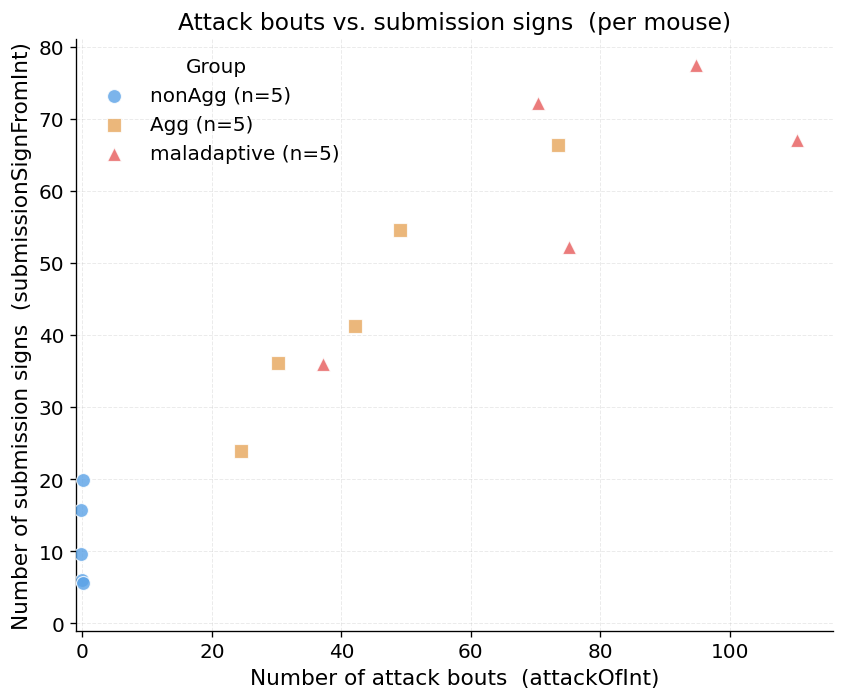

In [6]:
"""
Plot attack bouts (x) vs. submission signs (y) across the annotation dataset.

Each .annot file is a Bento annotation export containing two behaviors:
    attackOfInt
    submissionSignFromInt
A "bout" / "sign" = one (Start, Stop, Duration) row under that behavior header.

The script walks every mouse folder under DT_FOLDER, decides each mouse's group
from its ID, counts bouts in every .annot file, and produces a coloured scatter.

Run:  python plot_attack_vs_submission.py
Outputs (written to OUT_DIR):
    attack_vs_submission.png / .pdf   the figure
    bout_counts.csv                   the raw per-file counts behind the plot
"""

import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# ----------------------------------------------------------------------------- #
# CONFIG  — edit these
# ----------------------------------------------------------------------------- #
DT_FOLDER = Path(r"A:\rawData\compressedVideos_AVI\trainingSessions_DLC"
                 r"\fig1_trainingSessions_annotationsNoemie_non_agg_mal")

OUT_DIR = Path.cwd()            # where the figure + csv are saved

# "session" -> one point per .annot file (each mouse contributes ~3 points)
# "mouse"   -> one point per mouse (counts summed across that mouse's files)
MODE = "mouse"

JITTER = 0.25                   # tiny scatter so identical integer counts don't fully overlap (0 to disable)
LABEL_POINTS = False           # annotate each point with its mouse ID (gets busy with many points)

BEHAVIORS = {
    "attack":     "attackOfInt",            # -> x axis
    "submission": "submissionSignFromInt",  # -> y axis
}

# Mouse groups
GROUPS = {
    "Agg": ["975826", "975827", "975833", "978772", "978774", "988590",
            "997838", "1010820", "1010823", "1010826", "1029741"],
    "nonAgg": ["975830", "978775", "1010819", "997839", "997840", "997841",
               "1029736", "1029739", "1032216"],
    "maladaptive": ["978513", "978527", "978528", "1010832", "1013590",
                    "1034805", "1034814"],
}

GROUP_COLORS  = {"nonAgg": "#5AA2E6", "Agg": "#E6A55A", "maladaptive": "#E65A5A"}
GROUP_MARKERS = {"nonAgg": "o",       "Agg": "s",       "maladaptive": "^"}
GROUP_ORDER   = ["nonAgg", "Agg", "maladaptive"]

# ----------------------------------------------------------------------------- #
# Parsing
# ----------------------------------------------------------------------------- #
ID_TO_GROUP = {mid: g for g, ids in GROUPS.items() for mid in ids}
# longest IDs first so a 7-digit ID is preferred over any shorter coincidental match
_ID_PATTERNS = [(mid, re.compile(rf"(?<!\d){re.escape(mid)}(?!\d)"))
                for mid in sorted(ID_TO_GROUP, key=len, reverse=True)]

_ROW_RE = re.compile(r"^\s*\d+\s+\d+\s+\d+\s*$")  # a Start/Stop/Duration row


def mouse_id_from(text: str):
    """Return the known mouse ID found in a path/name, or None."""
    for mid, pat in _ID_PATTERNS:
        if pat.search(text):
            return mid
    return None


def count_bouts(annot_path: Path) -> dict:
    """Count rows under each behaviour header in one .annot file."""
    counts = {name: 0 for name in BEHAVIORS.values()}
    current = None
    with open(annot_path, "r", encoding="utf-8", errors="replace") as fh:
        for line in fh:
            stripped = line.strip()
            if stripped.startswith(">"):
                current = stripped[1:].strip()
            elif current in counts and _ROW_RE.match(line):
                counts[current] += 1
    return counts


def collect() -> pd.DataFrame:
    """Walk DT_FOLDER and build a per-file table of bout counts."""
    if not DT_FOLDER.exists():
        sys.exit(f"DT_FOLDER does not exist:\n  {DT_FOLDER}")

    rows = []
    annot_files = sorted(DT_FOLDER.rglob("*.annot"))
    if not annot_files:
        sys.exit(f"No .annot files found under:\n  {DT_FOLDER}")

    for f in annot_files:
        mid = mouse_id_from(str(f))
        if mid is None:
            print(f"  [skip] no known mouse ID in path: {f}")
            continue
        c = count_bouts(f)
        rows.append({
            "mouse_id": mid,
            "group": ID_TO_GROUP[mid],
            "file": f.name,
            "attack_bouts": c[BEHAVIORS["attack"]],
            "submission_signs": c[BEHAVIORS["submission"]],
        })

    df = pd.DataFrame(rows)
    if df.empty:
        sys.exit("Found .annot files but none matched a known mouse ID.")

    # sanity check: how many files per mouse?
    per_mouse = df.groupby("mouse_id").size()
    odd = per_mouse[per_mouse != 3]
    if len(odd):
        print("  [note] mice without exactly 3 .annot files:")
        for m, n in odd.items():
            print(f"         {m} ({ID_TO_GROUP[m]}): {n} file(s)")
    return df


# ----------------------------------------------------------------------------- #
# Plotting
# ----------------------------------------------------------------------------- #
def style():
    mpl.rcParams.update({
        "font.size": 12, "axes.titlesize": 14, "axes.labelsize": 13,
        "axes.spines.top": False, "axes.spines.right": False,
        "figure.dpi": 120, "savefig.dpi": 300,
    })


def make_plot(df: pd.DataFrame, mode: str):
    rng = np.random.default_rng(0)
    fig, ax = plt.subplots(figsize=(7.2, 6))

    for g in GROUP_ORDER:
        sub = df[df["group"] == g]
        if sub.empty:
            continue
        x = sub["attack_bouts"].to_numpy(float)
        y = sub["submission_signs"].to_numpy(float)
        if JITTER:
            x = x + rng.uniform(-JITTER, JITTER, x.shape)
            y = y + rng.uniform(-JITTER, JITTER, y.shape)
        ax.scatter(x, y, s=70, c=GROUP_COLORS[g], marker=GROUP_MARKERS[g], alpha=0.8,
                   edgecolors="white", linewidths=0.7,
                   label=f"{g} (n={len(sub)})", zorder=3)
        if LABEL_POINTS:
            for xi, yi, mid in zip(x, y, sub["mouse_id"]):
                ax.annotate(mid, (xi, yi), textcoords="offset points",
                            xytext=(4, 4), fontsize=7, color="0.3")

    unit = "per session" if mode == "session" else "per mouse"
    ax.set_xlabel(f"Number of attack bouts  (attackOfInt)")
    ax.set_ylabel(f"Number of submission signs  (submissionSignFromInt)")
    ax.set_title(f"Attack bouts vs. submission signs  ({unit})")
    ax.set_xlim(left=-1)
    ax.set_ylim(bottom=-1)
    ax.legend(title="Group", frameon=False, loc="best")
    ax.grid(True, alpha=0.25, linestyle="--", linewidth=0.6)
    fig.tight_layout()
    return fig


# ----------------------------------------------------------------------------- #
# Main
# ----------------------------------------------------------------------------- #
# ----------------------------------------------------------------------------- #
# Main — average across sessions, one point per mouse
# ----------------------------------------------------------------------------- #
# ----------------------------------------------------------------------------- #
# Main — average across sessions, one point per mouse
# ----------------------------------------------------------------------------- #
def main():
    style()
    df = collect()

    # -------------------------------------------------------------------------
    # Average the SESSION counts within each mouse
    # -------------------------------------------------------------------------
    if MODE == "mouse":
        plot_df = (
            df.groupby(["mouse_id", "group"], as_index=False)
              .agg(
                  attack_bouts=("attack_bouts", "mean"),
                  submission_signs=("submission_signs", "mean"),
                  n_sessions=("file", "count"),
              )
        )
    else:
        plot_df = df.copy()

    # -------------------------------------------------------------------------
    # Print session-level values
    # -------------------------------------------------------------------------
    print("\n===================================================")
    print("SESSION-LEVEL COUNTS")
    print("===================================================")

    print(
        df[
            [
                "mouse_id",
                "group",
                "file",
                "attack_bouts",
                "submission_signs",
            ]
        ]
        .sort_values(["group", "mouse_id", "file"])
        .to_string(index=False)
    )

    # -------------------------------------------------------------------------
    # Print per-mouse averages
    # -------------------------------------------------------------------------
    if MODE == "mouse":
        print("\n===================================================")
        print("AVERAGE PER MOUSE")
        print("===================================================")

        print(
            plot_df[
                [
                    "mouse_id",
                    "group",
                    "n_sessions",
                    "attack_bouts",
                    "submission_signs",
                ]
            ]
            .sort_values(["group", "mouse_id"])
            .to_string(index=False)
        )

    # -------------------------------------------------------------------------
    # Save tables
    # -------------------------------------------------------------------------
    OUT_DIR.mkdir(parents=True, exist_ok=True)

    # Raw session-level counts
    session_csv = OUT_DIR / "bout_counts_per_session.csv"
    df.sort_values(
        ["group", "mouse_id", "file"]
    ).to_csv(
        session_csv,
        index=False
    )

    # Mouse-level averages
    mouse_csv = OUT_DIR / "bout_counts_average_per_mouse.csv"

    if MODE == "mouse":
        plot_df.sort_values(
            ["group", "mouse_id"]
        ).to_csv(
            mouse_csv,
            index=False
        )

    # -------------------------------------------------------------------------
    # Plot
    # -------------------------------------------------------------------------
    fig = make_plot(plot_df, MODE)

    png = OUT_DIR / "attack_vs_submission_average_per_mouse.png"
    pdf = OUT_DIR / "attack_vs_submission_average_per_mouse.pdf"

    fig.savefig(png, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")

    # -------------------------------------------------------------------------
    # Summary
    # -------------------------------------------------------------------------
    print("\n===================================================")
    print("SUMMARY")
    print("===================================================")

    print(
        f"Parsed {len(df)} sessions "
        f"from {df['mouse_id'].nunique()} mice."
    )

    print(
        f"Plotted {len(plot_df)} points."
    )

    print("\nPoints per group:")
    print(
        plot_df.groupby("group")
        .size()
        .to_string()
    )

    print(
        f"\nSaved:\n"
        f"  {png}\n"
        f"  {pdf}\n"
        f"  {session_csv}\n"
        f"  {mouse_csv}"
    )

    plt.show()


if __name__ == "__main__":
    main()


SESSION-LEVEL SCORES
mouse_id       group  day  attack_score  sub_score
 1010820         Agg    2      0.011542   0.108396
 1010820         Agg    6      0.001901   0.030234
 1010820         Agg   12      0.113046   0.142557
 1010823         Agg    2      0.013798   0.068028
 1010823         Agg    6      0.141762   0.349681
 1010823         Agg   11      0.148614   0.054452
 1010826         Agg    2      0.251707   0.205941
 1010826         Agg    7      0.132941   0.163402
 1010826         Agg   12      0.022996   0.088126
 1029741         Agg    2      0.084138   0.222116
 1029741         Agg    6      0.125860   0.193157
 1029741         Agg   12      0.081357   0.141157
  975833         Agg    2      0.084707   0.014453
  975833         Agg    6      0.055483   0.149295
  975833         Agg   19      0.046311   0.117922
 1010832 maladaptive    5      0.092548   0.155349
 1010832 maladaptive   16      0.056044   0.092211
 1010832 maladaptive   19      0.006824   0.050640
 1013590 

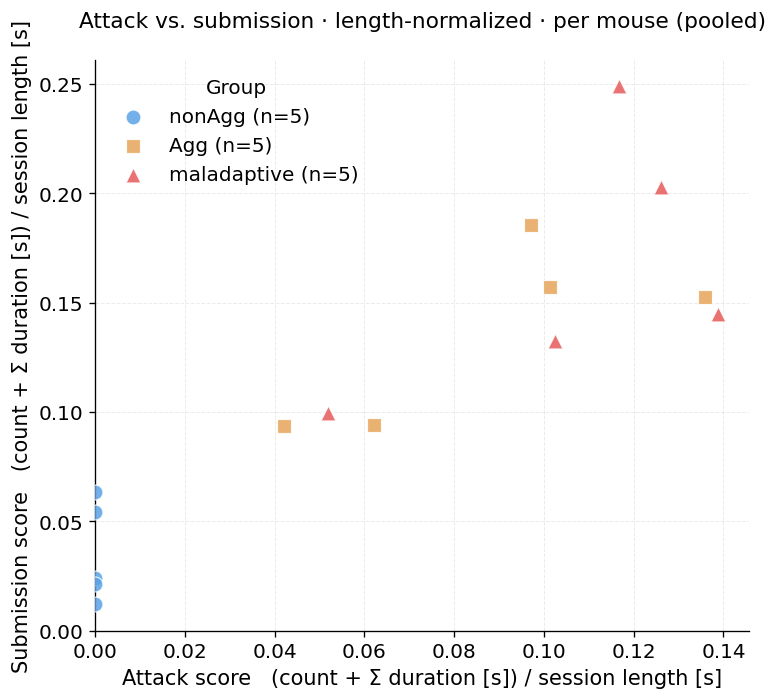

In [2]:
"""
Attack vs. submission scatter, where each axis is a COMBINED, length-normalized
score per behaviour:

    score = (number of bouts + total duration of bouts [s]) / session length [s]

    x = attack score      (attackOfInt)
    y = submission score  (submissionSignFromInt)

Counts and durations are read from each Bento .annot file; the session length
is taken from the header (Annotation stop time - Annotation start time, in
seconds) so sessions of slightly different length are comparable.

Sampling:
  * Agg / nonAgg            -> every session is a point.
  * maladaptive             -> only the FIRST session of each mouse (smallest
                              day number; days differ across mice, so "first"
                              is defined per mouse by the smallest day).

Run:  python plot_attack_vs_submission.py
Outputs (in OUT_DIR):
    attack_vs_submission.png / .pdf
    features_per_file.csv   every file: raw counts, durations, scores, used flag
    plotted_points.csv      exactly the points drawn (per session or per mouse)
"""

import os
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# ----------------------------------------------------------------------------- #
# CONFIG  — edit these
# ----------------------------------------------------------------------------- #
DT_FOLDER = Path(r"A:\rawData\compressedVideos_AVI\trainingSessions_DLC"
                 r"\fig1_trainingSessions_annotationsNoemie_non_agg_mal")

OUT_DIR = Path.cwd()

# "session" -> one point per .annot file
# "mouse"   -> one point per mouse (raw counts/durations/lengths pooled across
#              that mouse's used sessions, then the score recomputed)
MODE = "session"

MALADAPTIVE_FIRST_SESSION_ONLY = True   # keep only each maladaptive mouse's earliest-day session
JITTER = 0.0          # in score units; usually unnecessary (scores are continuous)
LABEL_POINTS = False  # annotate each point with its mouse ID

BEHAVIORS = {"attack": "attackOfInt", "submission": "submissionSignFromInt"}

# Mouse groups
GROUPS = {
    "Agg": ["975826", "975827", "975833", "978772", "978774", "988590",
            "997838", "1010820", "1010823", "1010826", "1029741"],
    "nonAgg": ["975830", "978775", "1010819", "997839", "997840", "997841",
               "1029736", "1029739", "1032216"],
    "maladaptive": ["978513", "978527", "978528", "1010832", "1013590",
                    "1034805", "1034814"],
}

group_colors  = {"nonAgg": "#5AA2E6", "Agg": "#E6A55A", "maladaptive": "#E65A5A"}
group_markers = {"nonAgg": "o",       "Agg": "s",       "maladaptive": "^"}
group_order   = ["nonAgg", "Agg", "maladaptive"]

# ----------------------------------------------------------------------------- #
# Parsing
# ----------------------------------------------------------------------------- #
ID_TO_GROUP = {mid: g for g, ids in GROUPS.items() for mid in ids}
_ID_PATTERNS = [(mid, re.compile(rf"(?<!\d){re.escape(mid)}(?!\d)"))
                for mid in sorted(ID_TO_GROUP, key=len, reverse=True)]

_ROW_RE   = re.compile(r"^\s*(\d+)\s+(\d+)\s+(\d+)\s*$")  # Start Stop Duration (frames)
_VIDEO_RE = re.compile(r"mouse(\d+)_Day(\d+)")            # mouse + day, like filtered_results
_DAY_RE   = re.compile(r"[Dd]ay(\d+)")                    # fallback day from filename


def mouse_id_from(text: str):
    for mid, pat in _ID_PATTERNS:
        if pat.search(text):
            return mid
    return None


def parse_annot(path: Path) -> dict:
    """Single pass: header length + per-behaviour bout count and summed duration."""
    start = stop = framerate = None
    video = None
    counts = {name: 0 for name in BEHAVIORS.values()}
    dur_frames = {name: 0 for name in BEHAVIORS.values()}
    current = None
    with open(path, "r", encoding="utf-8", errors="replace") as fh:
        for line in fh:
            s = line.strip()
            if s.startswith("Annotation start time:"):
                start = float(s.split(":", 1)[1])
            elif s.startswith("Annotation stop time:"):
                stop = float(s.split(":", 1)[1])
            elif s.startswith("Annotation framerate:"):
                framerate = float(s.split(":", 1)[1])
            elif line.lower().startswith("movie file"):
                rest = line.split(":", 1)[1].strip()
                video = os.path.splitext(re.split(r"[\\/]", rest)[-1])[0]
            elif s.startswith(">"):
                current = s[1:].strip()
            else:
                m = _ROW_RE.match(line)
                if current in counts and m:
                    counts[current] += 1
                    dur_frames[current] += int(m.group(3))
    return {"video": video, "start": start, "stop": stop,
            "framerate": framerate, "counts": counts, "dur_frames": dur_frames}


def mouse_day_from(path: Path, video):
    """(mouse_id, day) from the movie 'video' name; fall back to the filename."""
    if video:
        m = _VIDEO_RE.search(video)
        if m:
            return m.group(1), int(m.group(2))
    stem = path.stem
    md = _DAY_RE.search(stem)
    mid = mouse_id_from(stem) or mouse_id_from(str(path))
    return mid, (int(md.group(1)) if md else None)


def collect():
    if not DT_FOLDER.exists():
        sys.exit(f"DT_FOLDER does not exist:\n  {DT_FOLDER}")
    files = sorted(DT_FOLDER.rglob("*.annot"))
    if not files:
        sys.exit(f"No .annot files found under:\n  {DT_FOLDER}")

    rows, skipped = [], []
    for f in files:
        info = parse_annot(f)
        mid, day = mouse_day_from(f, info["video"])
        if mid is None or mid not in ID_TO_GROUP:
            skipped.append({"file": f.name, "reason": "no_known_mouse_id"}); continue
        if day is None:
            skipped.append({"file": f.name, "reason": "no_day"}); continue
        if info["start"] is None or info["stop"] is None:
            skipped.append({"file": f.name, "reason": "no_session_length"}); continue

        fr = info["framerate"] or 50.0
        len_sec = info["stop"] - info["start"]
        att, sub = BEHAVIORS["attack"], BEHAVIORS["submission"]
        rows.append({
            "mouse_id": mid, "group": ID_TO_GROUP[mid], "file": f.name,
            "day": day, "video": info["video"], "len_sec": len_sec,
            "n_attack": info["counts"][att],
            "n_sub":    info["counts"][sub],
            "attack_dur_sec": info["dur_frames"][att] / fr,
            "sub_dur_sec":    info["dur_frames"][sub] / fr,
        })

    df = pd.DataFrame(rows)
    skipped_df = pd.DataFrame(skipped)
    if df.empty:
        if not skipped_df.empty:
            print(skipped_df.to_string(index=False))
        sys.exit("No .annot files mapped to a group with a usable length.")

    df = df.sort_values(["group", "mouse_id", "day"]).reset_index(drop=True)

    # keep only the earliest-day session for maladaptive mice
    df["used_in_plot"] = True
    if MALADAPTIVE_FIRST_SESSION_ONLY:
        is_mal = df["group"] == "maladaptive"
        keep = df[is_mal].sort_values("day").groupby("mouse_id").head(1).index
        drop = df.index[is_mal].difference(keep)
        df.loc[drop, "used_in_plot"] = False

    return df, skipped_df


def add_scores(d: pd.DataFrame) -> pd.DataFrame:
    """score = (count + total duration[s]) / length[s], plus its components."""
    d = d.copy()
    d["attack_score"]     = (d["n_attack"] + d["attack_dur_sec"]) / d["len_sec"]
    d["sub_score"]        = (d["n_sub"]    + d["sub_dur_sec"])     / d["len_sec"]
    d["attack_rate_per_s"] = d["n_attack"] / d["len_sec"]
    d["attack_time_frac"]  = d["attack_dur_sec"] / d["len_sec"]
    d["sub_rate_per_s"]    = d["n_sub"] / d["len_sec"]
    d["sub_time_frac"]     = d["sub_dur_sec"] / d["len_sec"]
    return d


# ----------------------------------------------------------------------------- #
# Plotting
# ----------------------------------------------------------------------------- #
def style():
    mpl.rcParams.update({
        "font.size": 12, "axes.titlesize": 14, "axes.labelsize": 12.5,
        "axes.spines.top": False, "axes.spines.right": False,
        "figure.dpi": 120, "savefig.dpi": 300,
    })


def make_plot(plot_df: pd.DataFrame, mode: str):
    rng = np.random.default_rng(0)
    fig, ax = plt.subplots(figsize=(6.5, 6))
    for g in group_order:
        sub = plot_df[plot_df["group"] == g]
        if sub.empty:
            continue
        x = sub["attack_score"].to_numpy(float)
        y = sub["sub_score"].to_numpy(float)
        if JITTER:
            x = x + rng.uniform(-JITTER, JITTER, x.shape)
            y = y + rng.uniform(-JITTER, JITTER, y.shape)
        ax.scatter(x, y, s=80, c=group_colors[g], marker=group_markers[g], alpha=0.85,
                   edgecolors="white", linewidths=0.7,
                   label=f"{g} (n={len(sub)})", zorder=3)
        if LABEL_POINTS:
            for xi, yi, mid in zip(x, y, sub["mouse_id"]):
                ax.annotate(mid, (xi, yi), textcoords="offset points",
                            xytext=(4, 4), fontsize=7, color="0.3")

    unit = "per session" if mode == "session" else "per mouse (pooled)"
    ax.set_xlabel("Attack score   (count + Σ duration [s]) / session length [s]")
    ax.set_ylabel("Submission score   (count + Σ duration [s]) / session length [s]")
    ax.set_title(f"Attack vs. submission · length-normalized · {unit}\n", fontsize=13)
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    ax.margins(0.08)
    ax.legend(title="Group", frameon=False, loc="best")
    ax.grid(True, alpha=0.25, linestyle="--", linewidth=0.6)
    fig.tight_layout()
    return fig


# ----------------------------------------------------------------------------- #
# Main
# ----------------------------------------------------------------------------- #
# ----------------------------------------------------------------------------- #
# Main — ONE AVERAGE POINT PER MOUSE
# ----------------------------------------------------------------------------- #

def main():
    style()

    # ---------------------------------------------------------
    # 1. Load all sessions
    # ---------------------------------------------------------
    df, skipped_df = collect()

    # IMPORTANT:
    # collect() may mark later maladaptive sessions as unused.
    # We want ALL sessions for the per-mouse average,
    # so do NOT filter using used_in_plot here.
    used = df.copy()

    # ---------------------------------------------------------
    # 2. Calculate score for EACH SESSION first
    # ---------------------------------------------------------
    used = add_scores(used)

    # ---------------------------------------------------------
    # 3. Average session scores within each mouse
    # ---------------------------------------------------------
    plot_df = (
        used
        .groupby(["mouse_id", "group"], as_index=False)
        .agg(
            attack_score=("attack_score", "mean"),
            sub_score=("sub_score", "mean"),

            attack_rate_per_s=("attack_rate_per_s", "mean"),
            attack_time_frac=("attack_time_frac", "mean"),
            sub_rate_per_s=("sub_rate_per_s", "mean"),
            sub_time_frac=("sub_time_frac", "mean"),

            n_sessions=("day", "count"),
            first_day=("day", "min"),
            last_day=("day", "max"),
        )
    )

    # ---------------------------------------------------------
    # 4. Print sessions BEFORE averaging
    # ---------------------------------------------------------
    print("\n===================================================")
    print("SESSION-LEVEL SCORES")
    print("===================================================")

    print(
        used[
            [
                "mouse_id",
                "group",
                "day",
                "attack_score",
                "sub_score",
            ]
        ]
        .sort_values(["group", "mouse_id", "day"])
        .to_string(index=False)
    )

    # ---------------------------------------------------------
    # 5. Print mouse averages
    # ---------------------------------------------------------
    print("\n===================================================")
    print("AVERAGE PER MOUSE")
    print("===================================================")

    print(
        plot_df[
            [
                "mouse_id",
                "group",
                "n_sessions",
                "attack_score",
                "sub_score",
            ]
        ]
        .sort_values(["group", "mouse_id"])
        .to_string(index=False)
    )

    print(
        f"\nOriginal data: {len(used)} sessions "
        f"from {used['mouse_id'].nunique()} mice"
    )

    print(
        f"After averaging: {len(plot_df)} points "
        f"from {plot_df['mouse_id'].nunique()} mice"
    )

    # ---------------------------------------------------------
    # 6. Save tables
    # ---------------------------------------------------------
    OUT_DIR.mkdir(parents=True, exist_ok=True)

    used.sort_values(
        ["group", "mouse_id", "day"]
    ).to_csv(
        OUT_DIR / "features_per_session.csv",
        index=False
    )

    plot_df.sort_values(
        ["group", "mouse_id"]
    ).to_csv(
        OUT_DIR / "average_per_mouse.csv",
        index=False
    )

    if not skipped_df.empty:
        skipped_df.to_csv(
            OUT_DIR / "skipped.csv",
            index=False
        )

    # ---------------------------------------------------------
    # 7. Plot ONE POINT PER MOUSE
    # ---------------------------------------------------------
    fig = make_plot(plot_df, "mouse")

    png = OUT_DIR / "attack_vs_submission_average_per_mouse.png"
    pdf = OUT_DIR / "attack_vs_submission_average_per_mouse.pdf"

    fig.savefig(png, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")

    print("\n===================================================")
    print("POINTS PER GROUP")
    print("===================================================")

    print(
        plot_df.groupby("group")
        .size()
        .to_string()
    )

    print(
        f"\nSaved:\n"
        f"  {png}\n"
        f"  {pdf}\n"
        f"  {OUT_DIR / 'features_per_session.csv'}\n"
        f"  {OUT_DIR / 'average_per_mouse.csv'}"
    )

    plt.show()


if __name__ == "__main__":
    main()

In [3]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


DT_FOLDER = Path(
    r"A:\rawData\compressedVideos_AVI\trainingSessions_DLC"
    r"\fig1_trainingSessions_annotationsNoemie_non_agg_mal"
)

FPS = 50.0


Agg = [
    "975826", "975827", "975833", "978772", "978774", "988590",
    "997838", "1010820", "1010823", "1010826", "1029741"
]

nonAgg = [
    "975830", "978775", "1010819", "997839", "997840", "997841",
    "1029736", "1029739", "1032216"
]

maladaptive = [
    "978513", "978527", "978528",
    "1010832", "1013590", "1034805", "1034814"
]

saline_mice = maladaptive[:3]
psilo_mice = maladaptive[3:]


COLORS = {
    "Agg": "#E6A55A",
    "nonAgg": "#5AA2E6",
    "maladaptive baseline": "#E65A5A",
    "maladaptive Saline": "#22B24D",
    "maladaptive Psilocybin": "#8A2BE2",
}

MARKERS = {
    "Agg": "s",
    "nonAgg": "o",
    "maladaptive baseline": "^",
    "maladaptive Saline": "D",
    "maladaptive Psilocybin": "P",
}

SESSION_TITLES = {
    1: "Last day of first week",
    2: "First day of second week",
    3: "Last day of second week",
}


def parse_annot(path):

    text = path.read_text(
        encoding="utf-8",
        errors="replace"
    )

    # Mouse ID + experimental DayXX
    m = re.search(
        r"mouse(\d+)_Day(\d+)",
        text,
        re.IGNORECASE
    )

    if m is None:
        return None

    mouse = m.group(1)
    day = int(m.group(2))

    current = None

    attacks = []
    submissions = 0
    all_stop_frames = []

    for line in text.splitlines():

        s = line.strip()

        if s.startswith(">"):
            current = s[1:].strip()
            continue

        row = re.match(
            r"^\s*(\d+)\s+(\d+)\s+(\d+)\s*$",
            line
        )

        if row is None:
            continue

        start = int(row.group(1))
        stop = int(row.group(2))

        all_stop_frames.append(stop)

        if current == "attackOfInt":
            attacks.append(start)

        elif current == "submissionSignFromInt":
            submissions += 1

    duration_min = max(all_stop_frames) / FPS / 60

    return {
        "mouse": mouse,
        "day": day,
        "attacks": len(attacks),
        "submissions": submissions,
        "duration_min": duration_min,
        "attack_latency_s": (
            min(attacks) / FPS
            if attacks else np.nan
        )
    }

In [20]:
rows = []

for f in DT_FOLDER.rglob("*.annot"):

    r = parse_annot(f)

    if r is not None and r["mouse"] in Agg + nonAgg + maladaptive:
        rows.append(r)


df = pd.DataFrame(rows)


# Sort the three sessions chronologically WITHIN EACH MOUSE
df = df.sort_values(
    ["mouse", "day"]
).reset_index(drop=True)

df["session"] = (
    df.groupby("mouse").cumcount() + 1
)


def get_group(row):

    mouse = row["mouse"]
    session = row["session"]

    # Agg + nonAgg exist at ALL time points
    if mouse in Agg:
        return "Agg"

    if mouse in nonAgg:
        return "nonAgg"

    # Maladaptive before treatment
    if session == 1:
        return "maladaptive baseline"

    # Maladaptive after treatment
    if mouse in saline_mice:
        return "maladaptive Saline"

    if mouse in psilo_mice:
        return "maladaptive Psilocybin"


df["group"] = df.apply(
    get_group,
    axis=1
)


# Normalize the COUNTS only
df["attacks_per_min"] = (
    df["attacks"] / df["duration_min"]
)

df["submissions_per_min"] = (
    df["submissions"] / df["duration_min"]
)

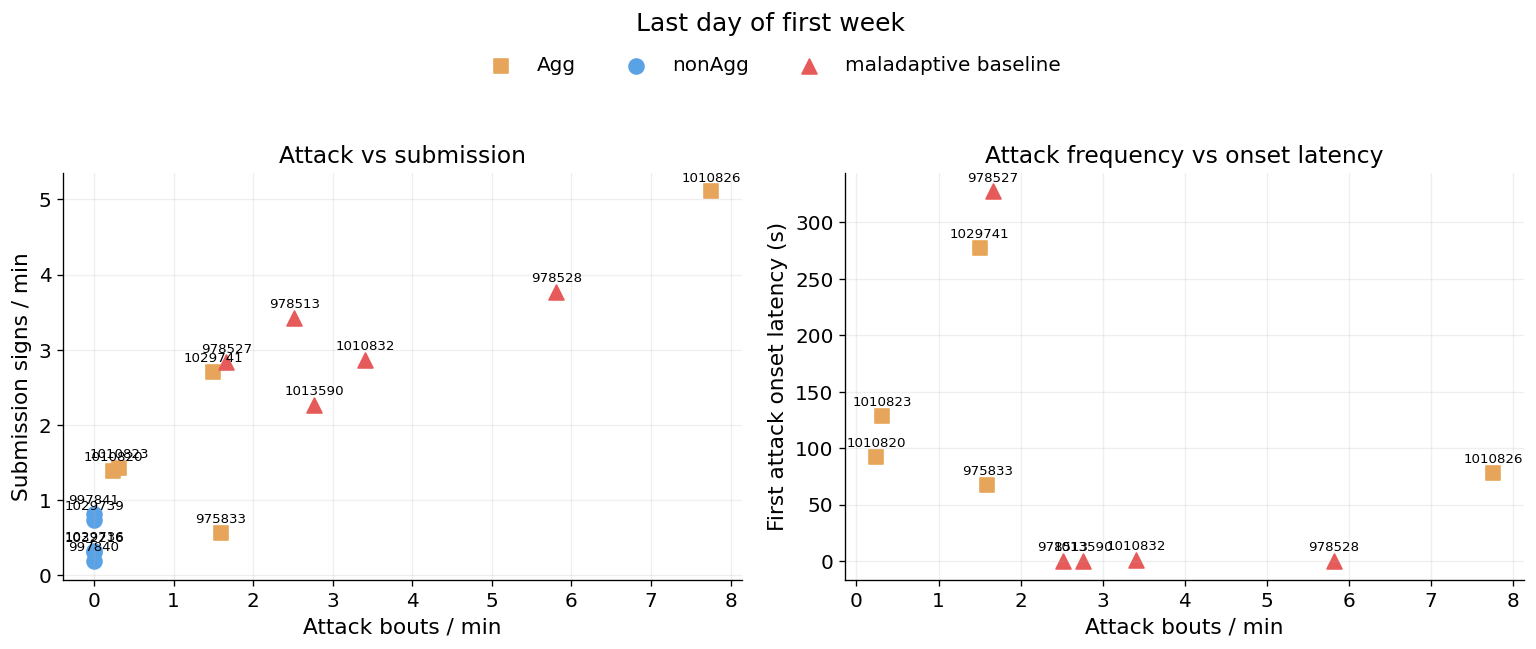

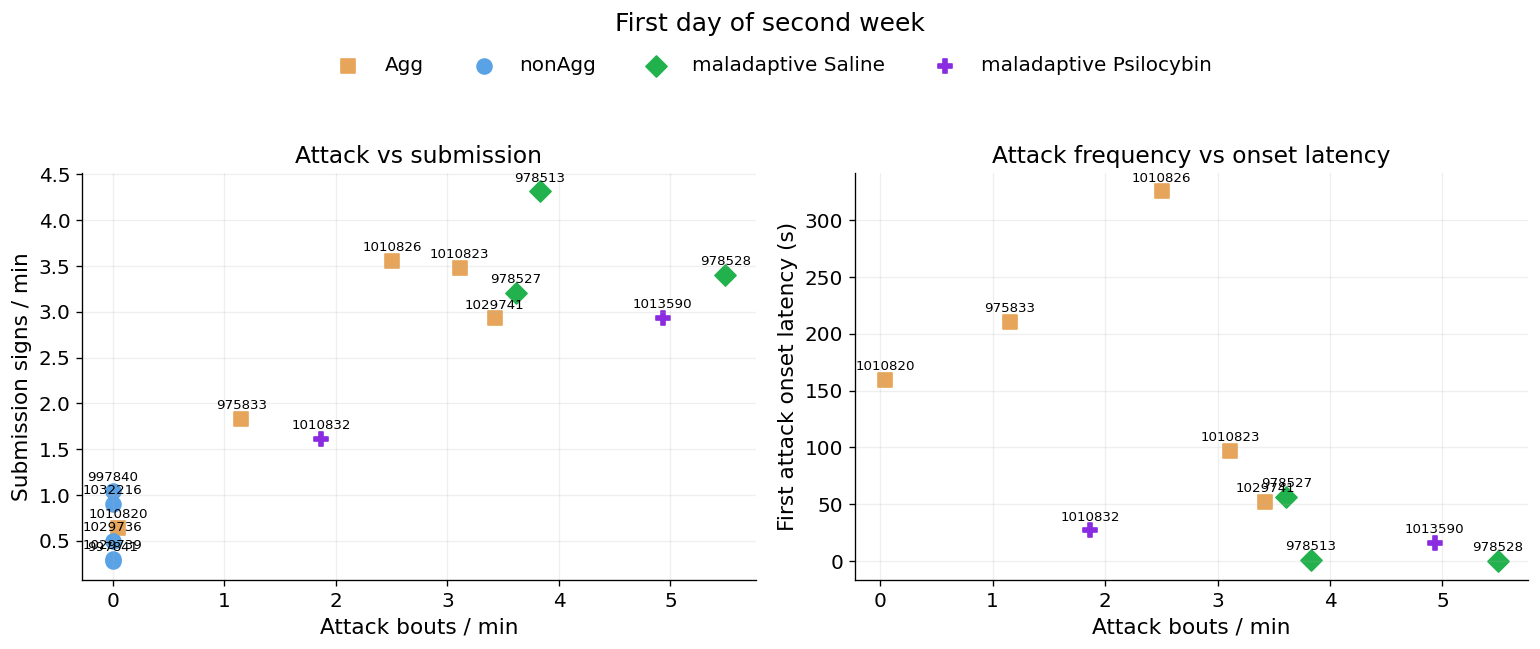

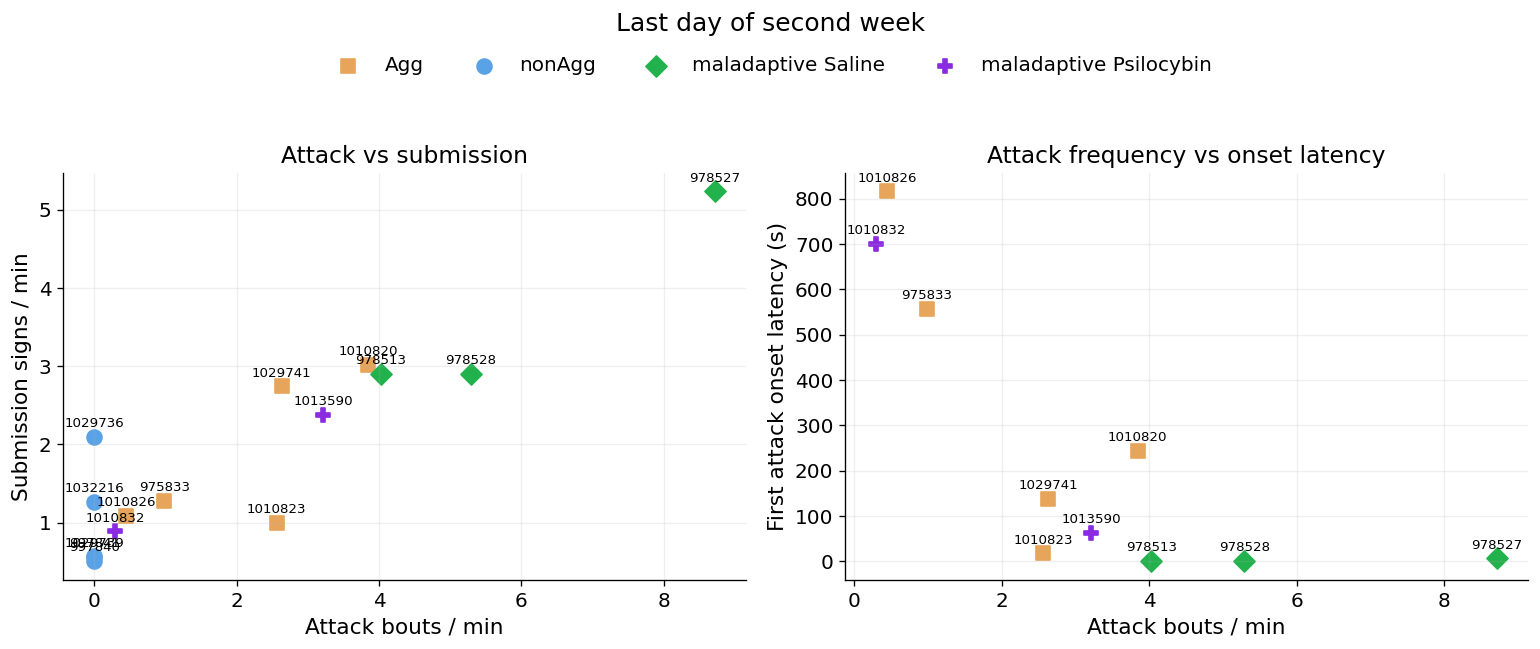

In [21]:
for session in [1, 2, 3]:

    d = df[df["session"] == session]

    fig, axes = plt.subplots(
        1, 2,
        figsize=(13, 5.5)
    )

    # =========================================================
    # LEFT:
    # Attacks/min vs Submissions/min
    # =========================================================

    ax = axes[0]

    for group in COLORS:

        sub = d[d["group"] == group]

        if sub.empty:
            continue

        ax.scatter(
            sub["attacks_per_min"],
            sub["submissions_per_min"],
            s=80,
            color=COLORS[group],
            marker=MARKERS[group],
            label=group
        )

        for _, r in sub.iterrows():

            ax.annotate(
                r["mouse"],
                (
                    r["attacks_per_min"],
                    r["submissions_per_min"]
                ),
                xytext=(0, 6),
                textcoords="offset points",
                ha="center",
                fontsize=8
            )

    ax.set_xlabel("Attack bouts / min")
    ax.set_ylabel("Submission signs / min")
    ax.set_title("Attack vs submission")

    ax.grid(alpha=0.2)


    # =========================================================
    # RIGHT:
    # Attacks/min vs Attack latency
    # =========================================================

    ax = axes[1]

    for group in COLORS:

        sub = d[
            (d["group"] == group) &
            d["attack_latency_s"].notna()
        ]

        if sub.empty:
            continue

        ax.scatter(
            sub["attacks_per_min"],
            sub["attack_latency_s"],
            s=80,
            color=COLORS[group],
            marker=MARKERS[group],
            label=group
        )

        for _, r in sub.iterrows():

            ax.annotate(
                r["mouse"],
                (
                    r["attacks_per_min"],
                    r["attack_latency_s"]
                ),
                xytext=(0, 6),
                textcoords="offset points",
                ha="center",
                fontsize=8
            )

    ax.set_xlabel("Attack bouts / min")
    ax.set_ylabel("First attack onset latency (s)")
    ax.set_title("Attack frequency vs onset latency")

    ax.grid(alpha=0.2)


    # =========================================================
    # FIGURE
    # =========================================================

    fig.suptitle(
        SESSION_TITLES[session],
        fontsize=15
    )

    # One common legend for both plots
    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.94),
        ncol=len(labels),
        frameon=False
    )

    plt.tight_layout(
        rect=[0, 0, 1, 0.88]
    )

    plt.show()